In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

# Import MOABB for dataset handling
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from reservoirpy import set_seed

warnings.filterwarnings("ignore")


# Import ReservoirPy for Echo State Network

# Set random seed for reproducibility
set_seed(42)
np.random.seed(42)


# useful link: https://moabb.neurotechx.com/docs/generated/moabb.paradigms.MotorImagery.html
# https://bnci-horizon-2020.eu/database/data-sets
# https://reservoirpy.readthedocs.io/en/latest/getting_started.html

In [2]:
# Initialize dataset
dataset = BNCI2014_001()

# Define paradigm (motor imagery with 4 classes)
paradigm = MotorImagery(
    n_classes=4,
    fmin=7,
    fmax=35,
    tmin=0.0,
    tmax=4.0,  # 4 seconds of motor imagery
    resample=128,  # Downsample to 128 Hz
)

Choosing from all possible events


In [32]:
# Get data
# specify subject id here e.g subjects=[1] to decrease data size for testing
X, y, metadata = paradigm.get_data(dataset=dataset)

In [33]:
X.shape, y.shape

((5184, 22, 513), (5184,))

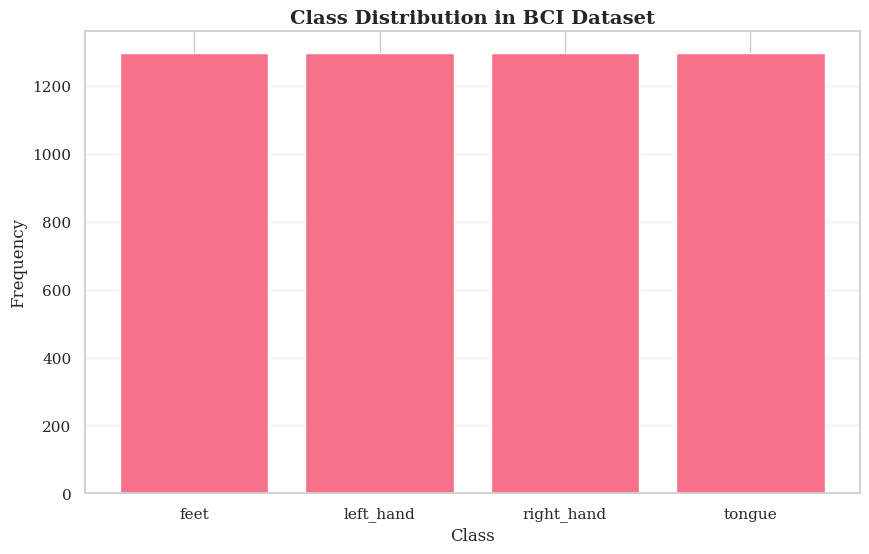

In [ ]:
# labels distribution plot
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar(unique, counts)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Class Distribution in BCI Dataset", fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)

In [37]:
# now using smaller portion for further epxloration
subjects = [1]

X, y, metadata = paradigm.get_data(dataset=dataset, subjects=subjects)

In [ ]:
X.shape, y.shape, np.unique(y)
# 576 examples, 22 channels, 512 timepoints, 4 classes

((576, 22, 513),
 (576,),
 array(['feet', 'left_hand', 'right_hand', 'tongue'], dtype='<U10'))

In [39]:
metadata.head()

,subject,session,run
0,1,0train,0
1,1,0train,0
2,1,0train,0
3,1,0train,0
4,1,0train,0


In [40]:
# Paradigm objects can also return the list of all dataset compatible. Here it will return the list all the imagery datasets from the MOABB.
compatible_datasets = paradigm.datasets
print([dataset.code for dataset in compatible_datasets])

100%|█████████████████████████████████████| 63.6M/63.6M [00:00<00:00, 54.1GB/s]
Unzipping contents of '/Users/dawidwozniak/mne_data/BIDS.zip' to '/Users/dawidwozniak/mne_data/BIDS.zip.unzip'


Download complete in 13s (60.7 MB)
['BNCI2014-001', 'BNCI2014-002', 'BNCI2014-004', 'BNCI2015-001', 'BNCI2015-004', 'Beetl2021-A', 'Beetl2021-B', 'Dreyer2023', 'Dreyer2023A', 'Dreyer2023B', 'Dreyer2023C', 'GrosseWentrup2009', 'Lee2019-MI', 'Liu2024', 'Schirrmeister2017', 'Shin2017A', 'Shin2017B', 'Weibo2014', 'Zhou2016']


In [ ]:
X.shape

(576, 22, 513)

In [ ]:
# taking indices for each class
feet_idx = np.where(y == "feet")
tongue_idx = np.where(y == "tongue")
right_hand_idx = np.where(y == "right_hand")
left_hand_idx = np.where(y == "left_hand")

In [80]:
X_feet_value = X[feet_idx]
X_tongue_value = X[tongue_idx]
X_right_hand_value = X[right_hand_idx]
X_left_hand_value = X[left_hand_idx]

assert X_feet_value.shape[0] == X_tongue_value.shape[0] == X_right_hand_value.shape[0] == X_left_hand_value.shape[0], (
    "Classes do not have equal number of examples"
)

In [75]:
def plot_class_average(X_class, class_name):
    x_class_avg = np.average(X_class, axis=0)
    x_class_avg = np.average(x_class_avg, axis=0)
    plt.plot(x_class_avg)
    plt.title(f"Average signal for class: {class_name}")
    plt.show()


def plot_all_classes_comparison(class_data_dict):
    """
    Plot all classes on a single subplot for comparison.

    Parameters:
    class_data_dict: dict with class names as keys and X data as values
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for idx, (class_name, X_class) in enumerate(class_data_dict.items()):
        x_class_avg = np.average(X_class, axis=0)
        x_class_avg = np.average(x_class_avg, axis=0)
        axes[idx].plot(x_class_avg)
        axes[idx].set_title(f"Average signal: {class_name}")
        axes[idx].set_xlabel("Timepoints")
        axes[idx].set_ylabel("Amplitude")
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

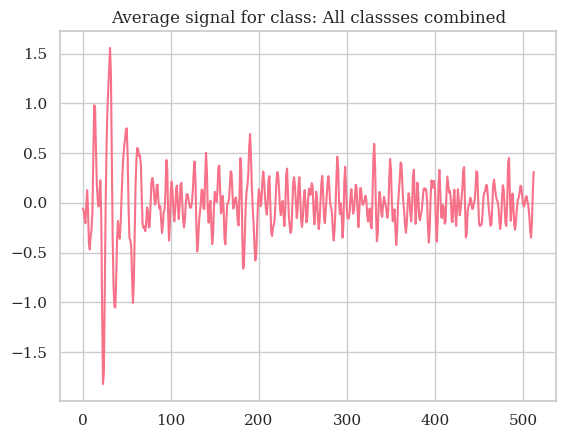

In [81]:
plot_class_average(X, "All classses combined")

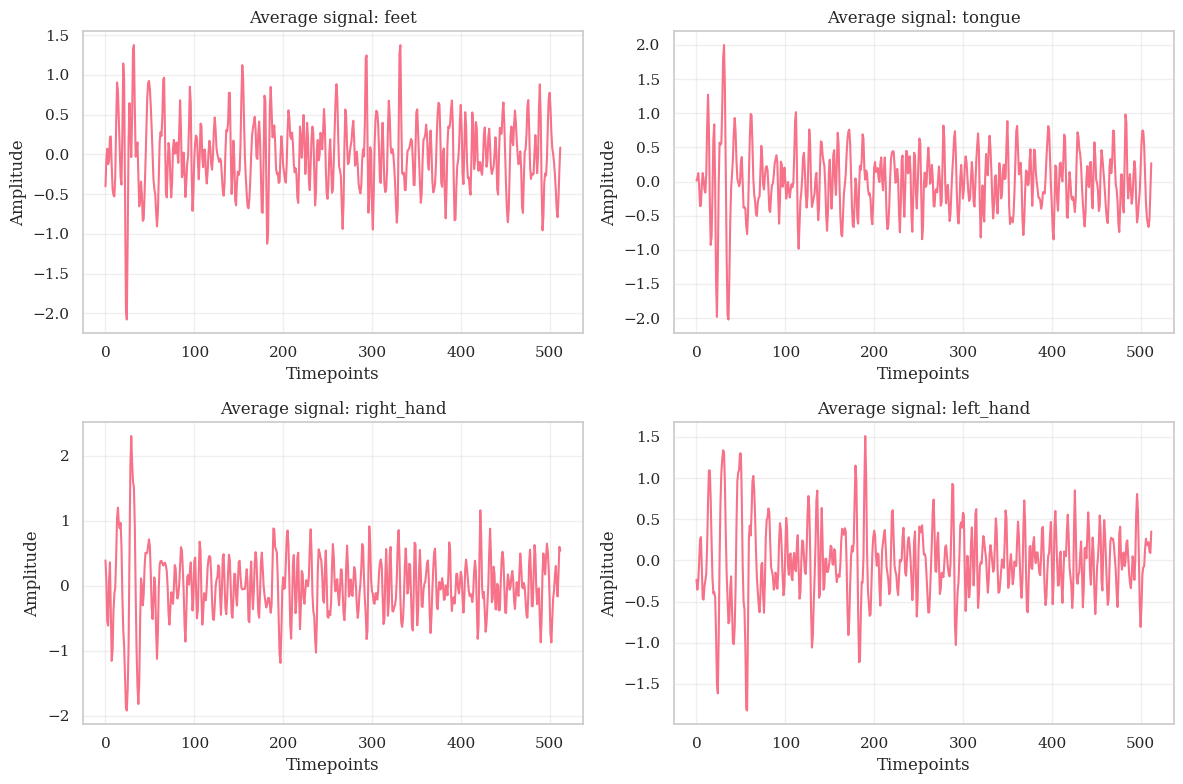

In [82]:
class_data = {"feet": X_feet_value, "tongue": X_tongue_value, "right_hand": X_right_hand_value, "left_hand": X_left_hand_value}
plot_all_classes_comparison(class_data)

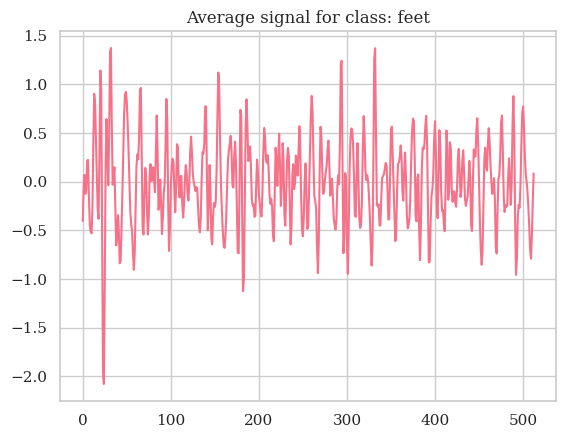

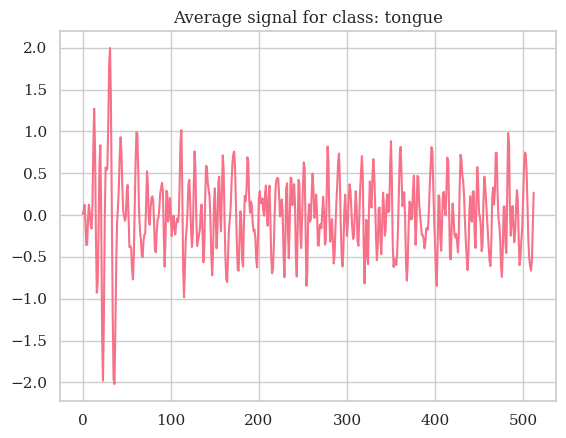

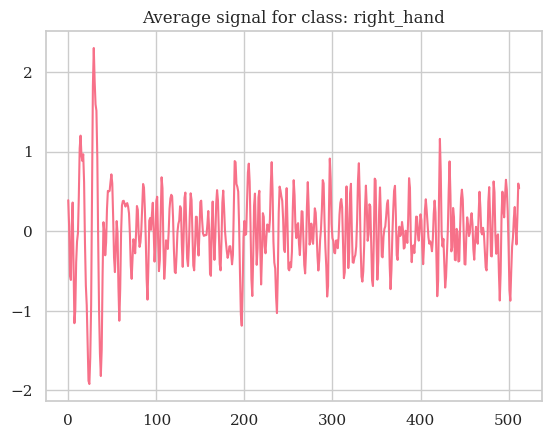

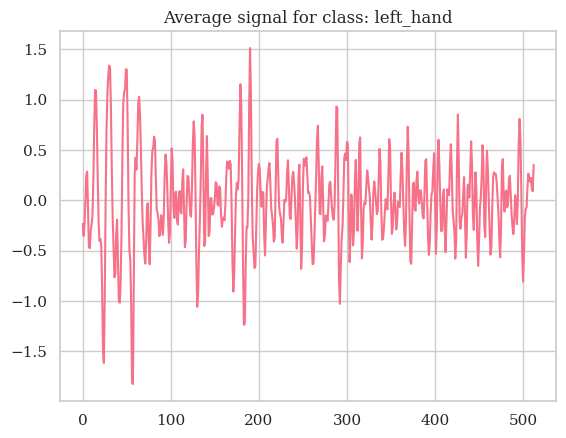

In [83]:
plot_class_average(X_feet_value, "feet")
plot_class_average(X_tongue_value, "tongue")
plot_class_average(X_right_hand_value, "right_hand")
plot_class_average(X_left_hand_value, "left_hand")